**PHASE - 01**

NLP Resourses downloads..


In [ ]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
!pip install pandas numpy nltk spacy scikit-learn matplotlib seaborn
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 94.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


spaCy provides pretrained NLP models.
This model allows us to perform:

tokenization

POS tagging

dependency parsing

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
!wget http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Electronics_5.json.gz

--2026-04-12 10:38:23--  http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Electronics_5.json.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 495854086 (473M) [application/x-gzip]
Saving to: ‘reviews_Electronics_5.json.gz’

reviews_Electronics 100%[===================>] 472.88M  77.9MB/s    in 6.7s    

2026-04-12 10:38:29 (71.1 MB/s) - ‘reviews_Electronics_5.json.gz’ saved [495854086/495854086]



loading tha dataset

In [ ]:
import gzip
import json
import pandas as pd

data = []

with gzip.open('reviews_Electronics_5.json.gz') as f:
    for i, line in enumerate(f):
        if i == 10000:   # load more data first
            break
        data.append(json.loads(line))

df = pd.DataFrame(data)


Kept requirred columns only


In [ ]:
df = df[['reviewText','overall']]
df.columns = ['Text','Score']

df.head()


,Text,Score
0,We got this GPS for my husband who is an (OTR)...,5.0
1,"I'm a professional OTR truck driver, and I bou...",1.0
2,"Well, what can I say. I've had this unit in m...",3.0
3,"Not going to write a long review, even thought...",2.0
4,I've had mine for a year and here's what we go...,1.0


broke into +ve and -ve, & removed neutrals..


In [ ]:
df = df[df['Score'] != 3]

df['Sentiment'] = df['Score'].apply(lambda x: 1 if x > 3 else 0)

df.head()

,Text,Score,Sentiment
0,We got this GPS for my husband who is an (OTR)...,5.0,1
1,"I'm a professional OTR truck driver, and I bou...",1.0,0
3,"Not going to write a long review, even thought...",2.0,0
4,I've had mine for a year and here's what we go...,1.0,0
5,I am using this with a Nook HD+. It works as d...,5.0,1


In [ ]:
print(df['Sentiment'].value_counts())

Sentiment
1    8156
0    1022
Name: count, dtype: int64


In [ ]:
positive = df[df['Sentiment'] == 1]
negative = df[df['Sentiment'] == 0]

min_count = min(len(positive), len(negative))

positive_sample = positive.sample(min_count, random_state=42)
negative_sample = negative.sample(min_count, random_state=42)

df = pd.concat([positive_sample, negative_sample])

In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(df['Sentiment'].value_counts())

Sentiment
1    1022
0    1022
Name: count, dtype: int64


In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-z\s]', '', text)

    return text

In [ ]:
df['clean_text'] = df['Text'].apply(clean_text)

df[['Text','clean_text']].head()

,Text,clean_text
0,CB radios were very popular in the 70s. 1 in 1...,cb radios were very popular in the s in cars...
1,This antenna did not work at all. The only goo...,this antenna did not work at all the only good...
2,I needed an extension that was not wireless so...,i needed an extension that was not wireless so...
3,I have been using this camcorder for more than...,i have been using this camcorder for more than...
4,Warranted for lifetime but 9 dollars return EA...,warranted for lifetime but dollars return eac...


Removing common words like, the , is , and etc..

In [ ]:
stop_words = set(stopwords.words('english'))

for word in ['not','no','never']:
    if word in stop_words:
        stop_words.remove(word)

lemmatize the words - Words into their origina form.

In [ ]:
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    words = nltk.word_tokenize(text)

    words = [w for w in words if w not in stop_words]

    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
df['processed_text'] = df['clean_text'].apply(preprocess)

In [ ]:
df[['clean_text','processed_text']].head()

,clean_text,processed_text
0,cb radios were very popular in the s in cars...,cb radio popular car one mid come back may las...
1,this antenna did not work at all the only good...,antenna not work good thing say cheap enough d...
2,i needed an extension that was not wireless so...,needed extension not wireless could reduce buf...
3,i have been using this camcorder for more than...,using camcorder month wanted compact camcorder...
4,warranted for lifetime but dollars return eac...,warranted lifetime dollar return even shipped ...


**PHASE - 02**

Feature Extraction using POS Tagging

In [ ]:
def extract_features(text):

    doc = nlp(text)

    nouns = []

    for token in doc:
        if token.pos_ == "NOUN":
            nouns.append(token.text)

    return nouns

Combining All Features into a list

In [ ]:
df['features'] = df['processed_text'].apply(extract_features)

df[['processed_text','features']].head()

,processed_text,features
0,cb radio popular car one mid come back may las...,"[car, mid, couple, year, radio, reason, review..."
1,antenna not work good thing say cheap enough d...,"[thing, trash]"
2,needed extension not wireless could reduce buf...,"[extension, wireless, buffering, movie, job]"
3,using camcorder month wanted compact camcorder...,"[camcorder, month, camcorder, convenience, min..."
4,warranted lifetime dollar return even shipped ...,"[lifetime, dollar, return, shipping, pay, ship..."


In [ ]:
from itertools import chain

all_features = list(chain.from_iterable(df['features']))

In [ ]:
from collections import Counter

feature_counts = Counter(all_features)

feature_counts.most_common(20)

[('time', 562),
 ('headphone', 547),
 ('product', 538),
 ('work', 528),
 ('quality', 490),
 ('sound', 487),
 ('cable', 480),
 ('use', 471),
 ('camera', 433),
 ('price', 432),
 ('problem', 425),
 ('year', 411),
 ('unit', 401),
 ('thing', 359),
 ('battery', 317),
 ('device', 307),
 ('radio', 305),
 ('card', 295),
 ('computer', 292),
 ('case', 271)]

Top 10 most common features

In [ ]:
top_features = feature_counts.most_common(10)

top_features

[('time', 562),
 ('headphone', 547),
 ('product', 538),
 ('work', 528),
 ('quality', 490),
 ('sound', 487),
 ('cable', 480),
 ('use', 471),
 ('camera', 433),
 ('price', 432)]

Visualization, and graph plot


In [ ]:
features = [x[0] for x in top_features]
counts = [x[1] for x in top_features]

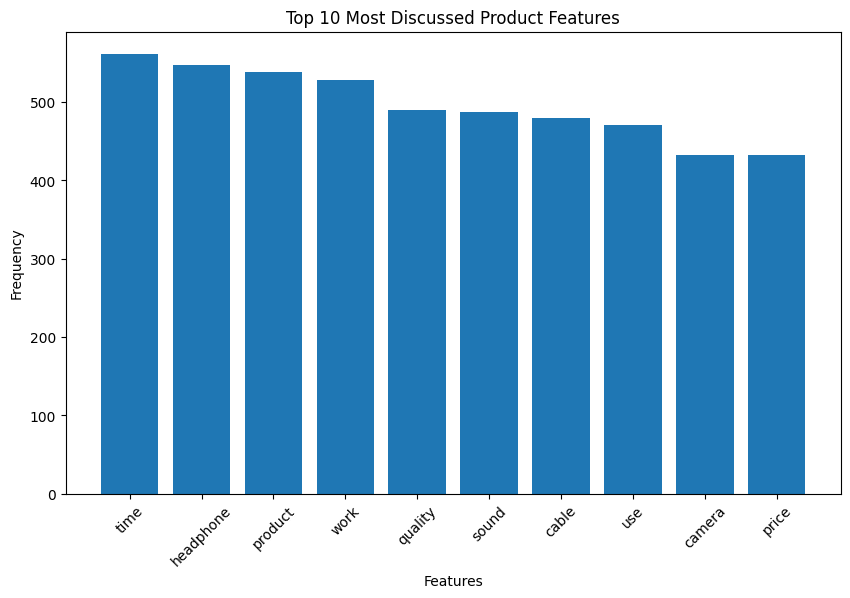

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(features, counts)

plt.title("Top 10 Most Discussed Product Features")

plt.xlabel("Features")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

A DataFrame is a table structure used for data analysis.

In [ ]:
feature_df = pd.DataFrame(top_features, columns=['Feature','Count'])

feature_df

,Feature,Count
0,time,562
1,headphone,547
2,product,538
3,work,528
4,quality,490
5,sound,487
6,cable,480
7,use,471
8,camera,433
9,price,432


PHASE - 03


In [ ]:
import nltk

def sentence_length(text):
    sentences = nltk.sent_tokenize(text)

    if len(sentences) == 0:
        return 0

    words = text.split()

    return len(words) / len(sentences)

In [ ]:
df['sentence_length'] = df['clean_text'].apply(sentence_length)

df[['clean_text','sentence_length']].head()

,clean_text,sentence_length
0,cb radios were very popular in the s in cars...,635.0
1,this antenna did not work at all the only good...,35.0
2,i needed an extension that was not wireless so...,26.0
3,i have been using this camcorder for more than...,110.0
4,warranted for lifetime but dollars return eac...,106.0


In [ ]:
def tree_depth(text):
    doc = nlp(text)

    max_depth = 0

    for token in doc:
        depth = 0
        current = token

        while current.head != current:
            depth += 1
            current = current.head

        if depth > max_depth:
            max_depth = depth

    return max_depth

In [ ]:
df['tree_depth'] = df['processed_text'].apply(tree_depth)

df[['processed_text','tree_depth']].head()

,processed_text,tree_depth
0,cb radio popular car one mid come back may las...,14
1,antenna not work good thing say cheap enough d...,4
2,needed extension not wireless could reduce buf...,4
3,using camcorder month wanted compact camcorder...,6
4,warranted lifetime dollar return even shipped ...,4


In [ ]:
def extract_feature_opinion(text):
    doc = nlp(text)
    pairs = []

    for token in doc:
        if token.dep_ == "amod" and token.head.pos_ == "NOUN":
            pairs.append((token.head.text, token.text))

    return pairs

In [ ]:
df['feature_opinion'] = df['processed_text'].apply(extract_feature_opinion)

df[['processed_text','feature_opinion']].head()

,processed_text,feature_opinion
0,cb radio popular car one mid come back may las...,"[(car, popular), (reason, many), (use, alive),..."
1,antenna not work good thing say cheap enough d...,"[(thing, good)]"
2,needed extension not wireless could reduce buf...,"[(extension, needed)]"
3,using camcorder month wanted compact camcorder...,"[(support, compact), (support, digital), (qual..."
4,warranted lifetime dollar return even shipped ...,"[(return, warranted), (shipping, multiple), (d..."


In [ ]:
df['feature_opinion'].head(10)

,feature_opinion
0,"[(car, popular), (reason, many), (use, alive),..."
1,"[(thing, good)]"
2,"[(extension, needed)]"
3,"[(support, compact), (support, digital), (qual..."
4,"[(return, warranted), (shipping, multiple), (d..."
5,"[(information, desirable), (information, young..."
6,"[(logo, rotate), (case, blue), (edition, speci..."
7,"[(feature, easy), (connection, nicethen), (app..."
8,"[(stuff, bad), (palmesque, much), (card, speci..."
9,"[(sand, futuristic), (tape, old), (range, amaz..."


In [ ]:
from spacy import displacy

doc = nlp(df['processed_text'].iloc[0])
displacy.render(doc, style='dep', jupyter=True)

PHASE - 04

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.8
)

X_text = vectorizer.fit_transform(df['processed_text']).toarray()

In [ ]:
def pos_features(text):
    doc = nlp(text)

    adj = 0
    noun = 0

    for token in doc:
        if token.pos_ == "ADJ":
            adj += 1
        if token.pos_ == "NOUN":
            noun += 1

    total = len(doc)

    return adj/total if total else 0, noun/total if total else 0

In [ ]:
df[['adj_ratio','noun_ratio']] = df['processed_text'].apply(
    lambda x: pd.Series(pos_features(x))
)

In [ ]:
import numpy as np

X_extra = df[['sentence_length','tree_depth','adj_ratio','noun_ratio']].values
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_extra_scaled = scaler.fit_transform(X_extra)
X = np.hstack((X_text, X_extra_scaled))
y = df['Sentiment']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8166259168704156
              precision    recall  f1-score   support

           0       0.83      0.80      0.82       208
           1       0.80      0.83      0.82       201

    accuracy                           0.82       409
   macro avg       0.82      0.82      0.82       409
weighted avg       0.82      0.82      0.82       409



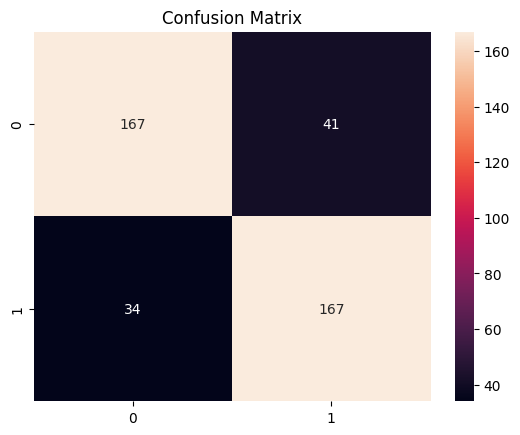

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X1 = X_text

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y, test_size=0.2, random_state=42
)

model1 = MultinomialNB()
model1.fit(X_train1, y_train1)

y_pred1 = model1.predict(X_test1)

print("TF-IDF Accuracy:", accuracy_score(y_test1, y_pred1))

TF-IDF Accuracy: 0.8190709046454768


In [ ]:
print("TF-IDF + Features Accuracy:", accuracy_score(y_test, y_pred))

TF-IDF + Features Accuracy: 0.8166259168704156
